<a href="https://colab.research.google.com/github/ltaf674/GEOG-761/blob/main/761_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing S2 Cloudles + Question 1

In [ ]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='earth-engine-testing-503702')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.8 MB/s eta 0:00:00


In [ ]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

In [ ]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [ ]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [ ]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

In [ ]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

In [ ]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

In [ ]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

In [ ]:
# Getting an eroor that add_cld_shdw_mask is not defined, I was unsure on how to solve this so I asked ai what this meant and what I had to do

# Adding the cloud-related bands (cloud probability and cloud mask)
def add_cld_shdw_mask(img):
    img_cloud = add_cloud_bands(img)
    img_cloud_shadow = add_shadow_bands(img_cloud)


 # Combining the cloud and shadow layers
    is_cld_shdw = (
        img_cloud_shadow.select('clouds')
        .add(img_cloud_shadow.select('shadows'))
        .gt(0)
    )

# Cleaning the mask
    is_cld_shdw = (
        is_cld_shdw
        .focalMin(2)
        .focalMax(BUFFER * 2 / 20)
        .reproject(
            crs=img.select([0]).projection(),
            scale=20
        )
        .rename('cloudmask')
    )
# Adding the finished cloud-shadow mask as a new band to the image
    return img_cloud_shadow.addBands(is_cld_shdw)

In [ ]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map # Using layers S2, dark pixels, shadows and clouds

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Question 2 - Changes and Figure

In [ ]:
# Changing the control variables

# First trial

AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.10
CLD_PRJ_DIST = 2
BUFFER = 75

In [ ]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)

display_map = display_cloud_layers_geemap(
    s2_sr_cld_col_eval_disp,
    AOI
)

display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

In [ ]:
# Trial 2

AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.10
CLD_PRJ_DIST = 1
BUFFER = 50

In [ ]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)

display_map = display_cloud_layers_geemap(
    s2_sr_cld_col_eval_disp,
    AOI
)

display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

In [ ]:
# Trial 3

AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.07
CLD_PRJ_DIST = 2
BUFFER = 100

In [ ]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)

display_map = display_cloud_layers_geemap(
    s2_sr_cld_col_eval_disp,
    AOI
)

display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Figure and Chosen Trial

In [ ]:
# Orginal Parameters
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

original_col = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
original_img = original_col.mosaic()

# Final Parameters
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.10
CLD_PRJ_DIST = 2
BUFFER = 75

final_col = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
final_img = final_col.mosaic()

In [ ]:
# Define a small region around Auckland for the figure
region = AOI.buffer(15000).bounds()

# RGB visualization settings
rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 2500,
    'gamma': 1.1
}

# RGB visualisations
original_rgb = original_img.visualize(**rgb_vis)
final_rgb = final_img.visualize(**rgb_vis)

# Cloudmask visualisations
original_mask = original_img.select('cloudmask').selfMask().visualize(
    palette=['orange']
)

final_mask = final_img.select('cloudmask').selfMask().visualize(
    palette=['orange']
)

# Cloudmask over Sentinel-2 imagery
original_display = original_rgb.blend(original_mask)
final_display = final_rgb.blend(final_mask)

In [ ]:
# Original component layers
original_clouds = original_img.select('clouds').selfMask().visualize(
    palette=['magenta']
)

original_dark = original_img.select('dark_pixels').selfMask().visualize(
    palette=['orange']
)

original_shadows = original_img.select('shadows').selfMask().visualize(
    palette=['yellow']
)

# Final component layers
final_clouds = final_img.select('clouds').selfMask().visualize(
    palette=['magenta']
)

final_dark = final_img.select('dark_pixels').selfMask().visualize(
    palette=['orange']
)

final_shadows = final_img.select('shadows').selfMask().visualize(
    palette=['yellow']
)

In [ ]:
rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 2500,
    'gamma': 1.1
}

original_rgb = original_img.visualize(**rgb_vis)
final_rgb = final_img.visualize(**rgb_vis)

In [ ]:
# Original: RGB + clouds + dark pixels + shadows
original_components = (
    original_rgb
    .blend(original_clouds)
    .blend(original_dark)
    .blend(original_shadows)
)

# Final: RGB + clouds + dark pixels + shadows
final_components = (
    final_rgb
    .blend(final_clouds)
    .blend(final_dark)
    .blend(final_shadows)
)

In [ ]:
original_mask = original_img.select('cloudmask').selfMask().visualize(
    palette=['red']
)

final_mask = final_img.select('cloudmask').selfMask().visualize(
    palette=['red']
)

original_mask_display = original_rgb.blend(original_mask)
final_mask_display = final_rgb.blend(final_mask)

In [29]:
region = AOI.buffer(15000).bounds()

original_components_array = geemap.ee_to_numpy(
    original_components,
    region=region,
    scale=20
)

final_components_array = geemap.ee_to_numpy(
    final_components,
    region=region,
    scale=20
)

original_mask_array = geemap.ee_to_numpy(
    original_mask_display,
    region=region,
    scale=20
)

final_mask_array = geemap.ee_to_numpy(
    final_mask_display,
    region=region,
    scale=20
)

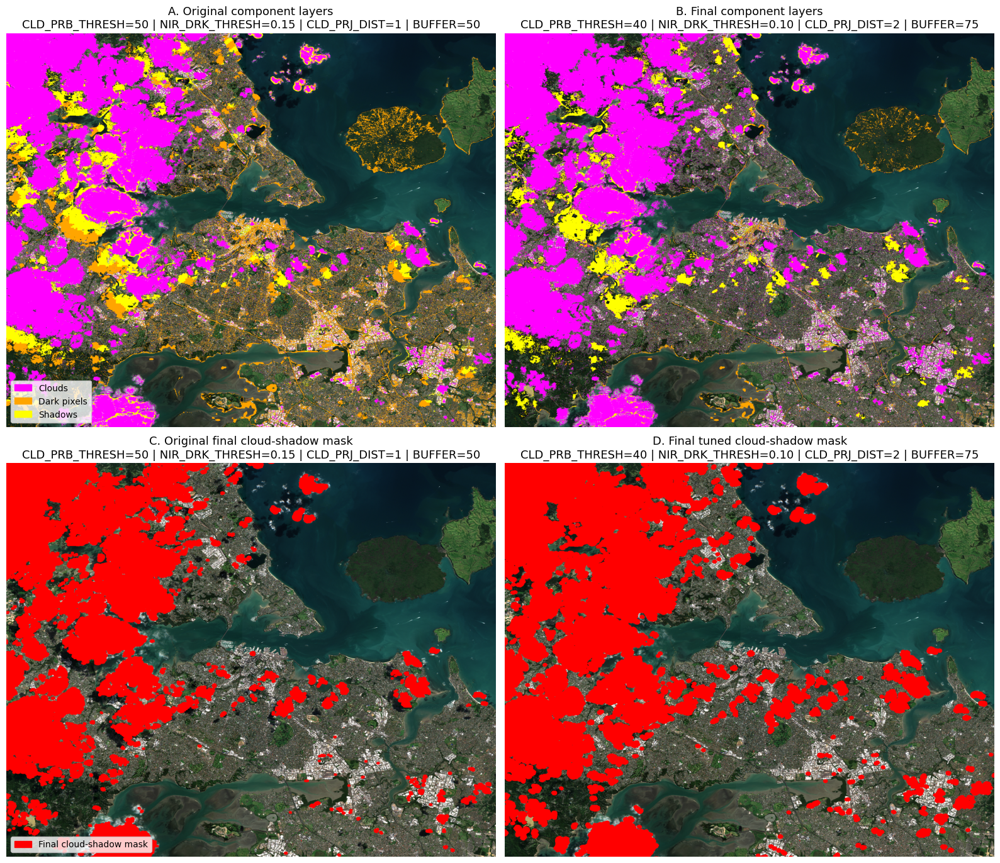

In [30]:
# I first made a simple two-panel figure comparing only the original
# and final combined cloud-shadow masks.

# I then decided to expand the figure so I could also show how the
# individual cloud, dark-pixel and shadow components changed after
# adjusting the parameters.
#With the help of AI, I made a figure show a 4 panel comparison

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Parameter labels
orig_params = (
    "CLD_PRB_THRESH=50 | NIR_DRK_THRESH=0.15 | "
    "CLD_PRJ_DIST=1 | BUFFER=50"
)

final_params = (
    "CLD_PRB_THRESH=40 | NIR_DRK_THRESH=0.10 | "
    "CLD_PRJ_DIST=2 | BUFFER=75"
)

# Legend items
component_legend = [
    mpatches.Patch(color='magenta', label='Clouds'),
    mpatches.Patch(color='orange', label='Dark pixels'),
    mpatches.Patch(color='yellow', label='Shadows')
]

mask_legend = [
    mpatches.Patch(color='red', label='Final cloud-shadow mask')
]

# Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# A. Original components
axes[0, 0].imshow(original_components_array)
axes[0, 0].set_title(
    "A. Original component layers\n" + orig_params,
    fontsize=13
)
axes[0, 0].axis("off")
axes[0, 0].legend(
    handles=component_legend,
    loc="lower left",
    fontsize=10,
    frameon=True
)

# B. Final components
axes[0, 1].imshow(final_components_array)
axes[0, 1].set_title(
    "B. Final component layers\n" + final_params,
    fontsize=13
)
axes[0, 1].axis("off")

# C. Original final mask
axes[1, 0].imshow(original_mask_array)
axes[1, 0].set_title(
    "C. Original final cloud-shadow mask\n" + orig_params,
    fontsize=13
)
axes[1, 0].axis("off")
axes[1, 0].legend(
    handles=mask_legend,
    loc="lower left",
    fontsize=10,
    frameon=True
)

# D. Final tuned mask
axes[1, 1].imshow(final_mask_array)
axes[1, 1].set_title(
    "D. Final tuned cloud-shadow mask\n" + final_params,
    fontsize=13
)
axes[1, 1].axis("off")

plt.tight_layout()

plt.savefig(
    "cloud_mask_comparison_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Question 3:

In [31]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.10
CLD_PRJ_DIST = 2
BUFFER = 75

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [32]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img


In [33]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [34]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Question 4:

In [35]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [36]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [37]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [38]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")

Cloud samples: 727
Clear samples: 4310
Edge samples: 1930


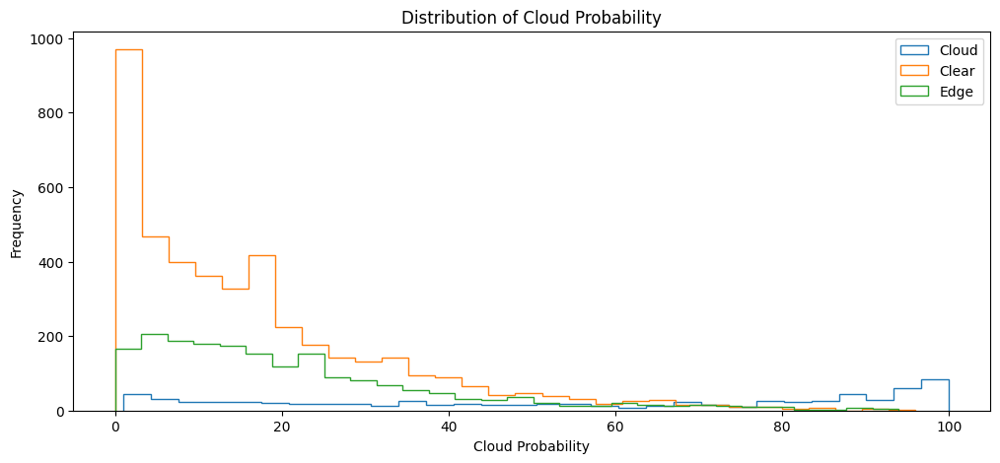

In [39]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

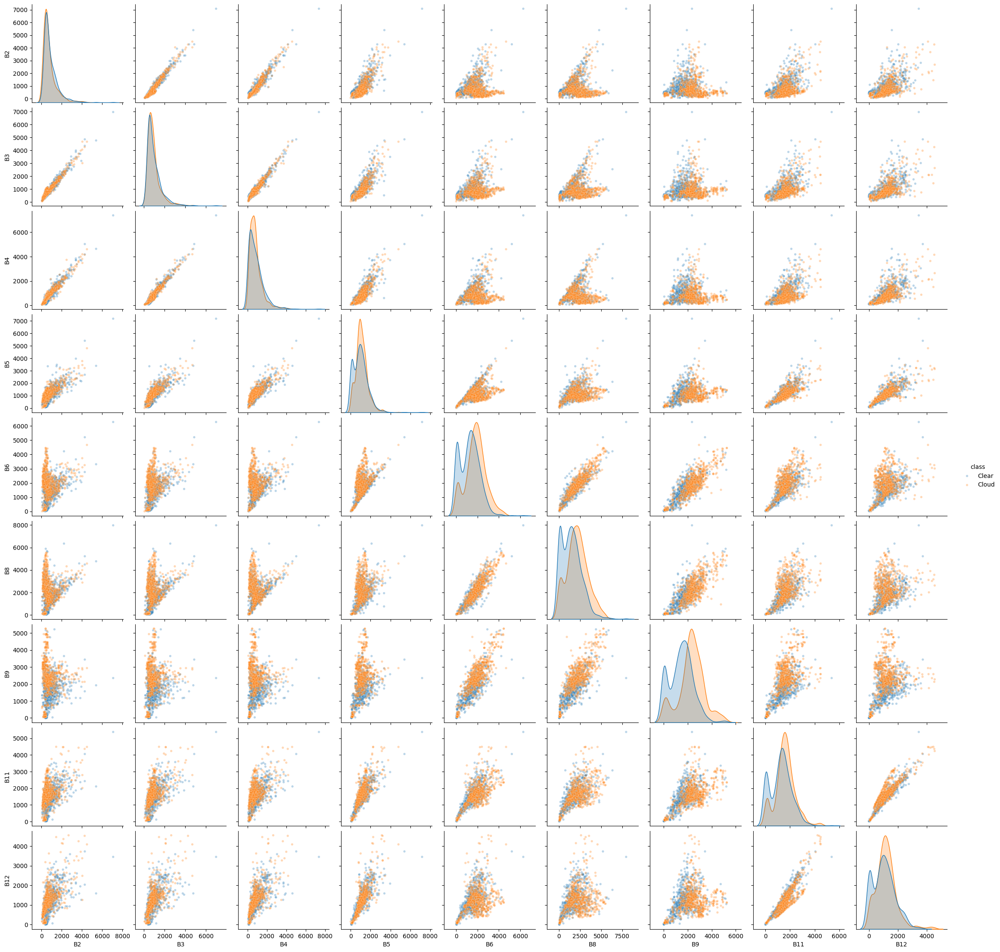

In [40]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


Quesiton 6:

In [41]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B2', 'B3', 'B4']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())

predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


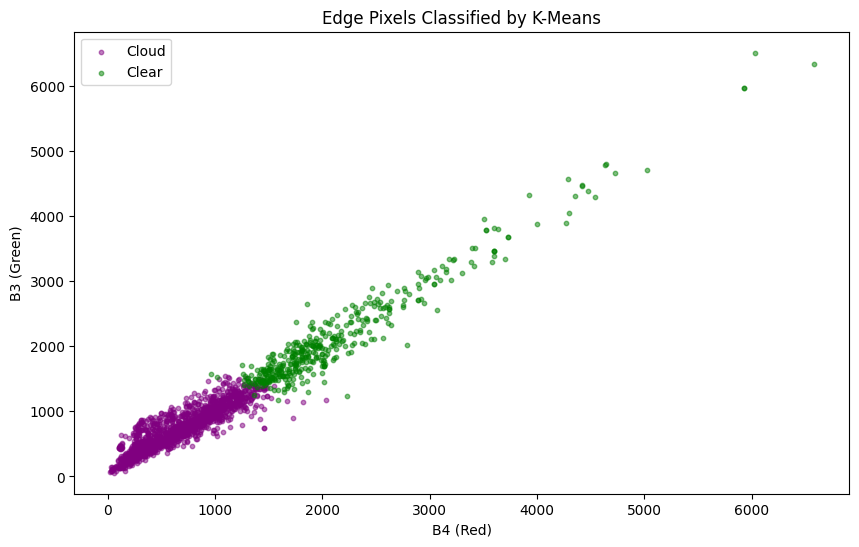

In [42]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B4 vs B3 colored by predicted class ### CHANGE THIS TO YOUR OTHER BANDS ###
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B4 (Red)')
plt.ylabel('B3 (Green)')
plt.title('Edge Pixels Classified by K-Means')
plt.legend()
plt.show()

Export to Earth Engine FC:

In [43]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

In [44]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')

In [45]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Exercise:

In [46]:
# Preparing balanced cloud and clear samples for K-means.
# The first run uses the default visible bands B2, B3 and B4.
# K-means does not use the class labels during clustering; the labels are kept so the two resulting clusters can later be identified as either Cloud or Clear.

# Using the balanced cloud and clear samples from earlier
train_df = balanced_df[
    balanced_df['class'].isin(['Cloud', 'Clear'])
]

# Default bands
features = ['B2', 'B3', 'B4']

X_train = train_df[features].values

y_train = (
    train_df['class'] == 'Cloud'
).astype(int).values

In [47]:
# Fit an unsupervised K-means model using two clusters.
# The model groups pixels based on spectral similarity rather than
# being told which pixels are Cloud or Clear.

kmeans = KMeans(
    n_clusters=2,
    random_state=42
).fit(X_train)

labels, counts = np.unique(
    kmeans.labels_[y_train == 0],
    return_counts=True
)

clear_cluster = labels[np.argmax(counts)]

labels, counts = np.unique(
    kmeans.labels_[y_train == 1],
    return_counts=True
)

cloud_cluster = labels[np.argmax(counts)]

print("Clear cluster:", clear_cluster)
print("Cloud cluster:", cloud_cluster)

Clear cluster: 1
Cloud cluster: 1


In [48]:
# Applying the trained K-means model to the uncertain cloud-edge pixels

edge_features = edge_df[features].values

edge_clusters = kmeans.predict(edge_features)

edge_df['predicted_class'] = [
    'Cloud' if c == cloud_cluster else 'Clear'
    for c in edge_clusters
]

print(edge_df['predicted_class'].value_counts())

predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


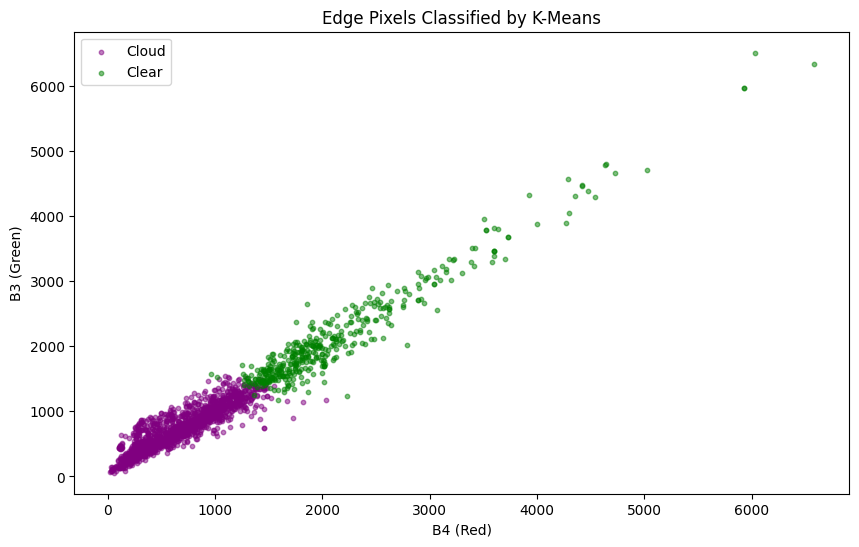

In [49]:
# Counting of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot
plt.figure(figsize=(10, 6))

for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]

    plt.scatter(
        subset['B4'],
        subset['B3'],
        label=label,
        alpha=0.5,
        s=10,
        c=color
    )

plt.xlabel('B4 (Red)')
plt.ylabel('B3 (Green)')
plt.title('Edge Pixels Classified by K-Means')
plt.legend()
plt.show()

In [50]:
# Re-running K-means using the bands selected in Question 5.
# B9, B11 and B12 showed better cloud/clear separation in the pair plot,

# Using the bands selected in Question 5
features = ['B9', 'B11', 'B12']

X_train = train_df[features].values

kmeans = KMeans(
    n_clusters=2,
    random_state=42
).fit(X_train)

labels, counts = np.unique(
    kmeans.labels_[y_train == 0],
    return_counts=True
)
clear_cluster = labels[np.argmax(counts)]

labels, counts = np.unique(
    kmeans.labels_[y_train == 1],
    return_counts=True
)
cloud_cluster = labels[np.argmax(counts)]

print("Clear cluster:", clear_cluster)
print("Cloud cluster:", cloud_cluster)

Clear cluster: 0
Cloud cluster: 0


In [51]:
edge_features = edge_df[features].values

edge_clusters = kmeans.predict(edge_features)

edge_df['predicted_class'] = [
    'Cloud' if c == cloud_cluster else 'Clear'
    for c in edge_clusters
]

print(edge_df['predicted_class'].value_counts())

predicted_class
Cloud    1309
Clear     621
Name: count, dtype: int64


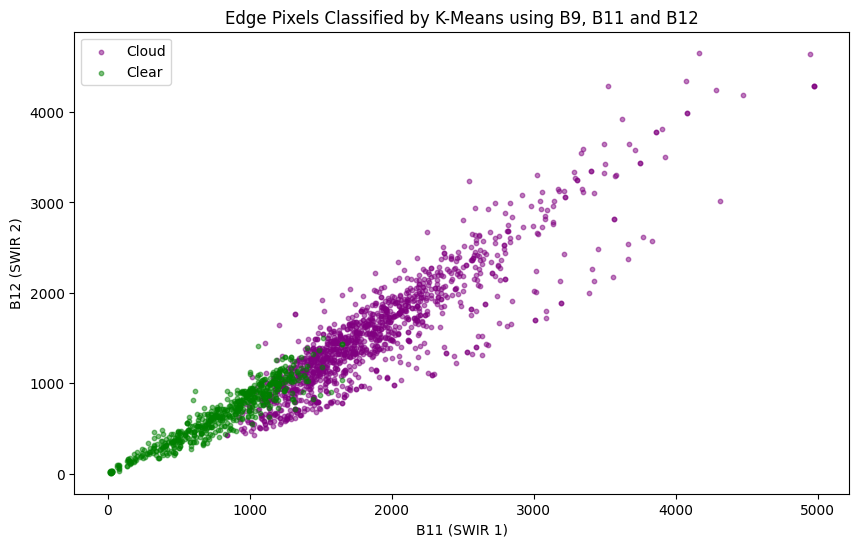

In [52]:
plt.figure(figsize=(10, 6))

for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]

    plt.scatter(
        subset['B11'],
        subset['B12'],
        label=label,
        alpha=0.5,
        s=10,
        c=color
    )

plt.xlabel('B11 (SWIR 1)')
plt.ylabel('B12 (SWIR 2)')
plt.title('Edge Pixels Classified by K-Means using B9, B11 and B12')
plt.legend()
plt.show()

In [56]:
# The original sampling was concentrated around downtown Auckland.
# For Q6, I increased the sampling region to include a wider range of
# land-cover types such as urban areas, forest, coast and rural land.
# This should make the K-means training data more representative of the full Sentinel-2 scene.

large_region = AOI.buffer(30000).bounds()

def sample_zones_large(img, region, edge_buffer=20):

    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()

    clear_interior = cloudmask.Not().selfMask()

    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B9', 'B11', 'B12']

    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples_large = img_for_sampling.updateMask(cloud_interior).sample(
        region=region,
        scale=20,
        numPixels=8000,
        seed=10,
        geometries=True
    )

    clear_samples_large = img_for_sampling.updateMask(clear_interior).sample(
        region=region,
        scale=20,
        numPixels=8000,
        seed=11,
        geometries=True
    )

    edge_samples_large = img_for_sampling.updateMask(cloud_edge).sample(
        region=region,
        scale=20,
        numPixels=8000,
        seed=12,
        geometries=True
    )

    return cloud_samples_large, clear_samples_large, edge_samples_large

In [57]:
cloud_samples_large, clear_samples_large, edge_samples_large = sample_zones_large(
    s2_sr_mosaic,
    large_region
)

print("Large-area cloud samples:", cloud_samples_large.size().getInfo())
print("Large-area clear samples:", clear_samples_large.size().getInfo())
print("Large-area edge samples:", edge_samples_large.size().getInfo())

Large-area cloud samples: 1201
Large-area clear samples: 6701
Large-area edge samples: 1740


In [59]:
# Visualising the expanded sampling

sample_map = geemap.Map(basemap='HYBRID')
sample_map.centerObject(large_region, 9)

sample_map.addLayer(
    s2_sr_mosaic,
    {'bands': ['B4', 'B3', 'B2'],
     'min': 0,
     'max': 2500,
     'gamma': 1.1},
    'Sentinel-2 RGB'
)

sample_map.addLayer(
    cloud_samples_large.style(color='purple', pointSize=3),
    {},
    'Cloud samples'
)

sample_map.addLayer(
    clear_samples_large.style(color='green', pointSize=3),
    {},
    'Clear samples'
)

sample_map.addLayer(
    edge_samples_large.style(color='yellow', pointSize=3),
    {},
    'Edge samples'
)

sample_map

Map(center=[-36.84828712113526, 174.76369671023667], controls=(WidgetControl(options=['position', 'transparent…

In [61]:
# The expanded sampling produced many more clear than cloud samples.
# I balanced the two classes before retraining K-means so that the
# larger clear class does not dominate the clustering.

# Converting the new large-area Earth Engine samples to pandas DataFrames
# Earth Engine limits large getInfo() requests, so I capped the clear
# sample collection at 5000 features before converting it to pandas.
# Cloud and edge samples were already below this limit.
cloud_df_large = fc_to_df(cloud_samples_large.limit(5000))
clear_df_large = fc_to_df(clear_samples_large.limit(5000))
edge_df_large = fc_to_df(edge_samples_large.limit(5000))

cloud_df_large['class'] = 'Cloud'
clear_df_large['class'] = 'Clear'

print("Cloud samples:", len(cloud_df_large))
print("Clear samples:", len(clear_df_large))
print("Edge samples:", len(edge_df_large))

Cloud samples: 1201
Clear samples: 5000
Edge samples: 1740


In [62]:
# Retraining K-means using the wider-area, balanced samples.
# This should make the model more representative of multiple
# land-cover types across the full scene rather than just downtown Auckland.

train_large_df = pd.concat(
    [cloud_df_large, clear_df_large],
    ignore_index=True
)

min_count = train_large_df['class'].value_counts().min()

balanced_large_df = (
    train_large_df
    .groupby('class', group_keys=False)
    .sample(n=min_count, random_state=42)
)

print(balanced_large_df['class'].value_counts())

class
Clear    1201
Cloud    1201
Name: count, dtype: int64


In [63]:
features = ['B9', 'B11', 'B12']

X_train_large = balanced_large_df[features].values
y_train_large = (
    balanced_large_df['class'] == 'Cloud'
).astype(int).values

kmeans_large = KMeans(
    n_clusters=2,
    random_state=42
).fit(X_train_large)

labels, counts = np.unique(
    kmeans_large.labels_[y_train_large == 0],
    return_counts=True
)
clear_cluster_large = labels[np.argmax(counts)]

labels, counts = np.unique(
    kmeans_large.labels_[y_train_large == 1],
    return_counts=True
)
cloud_cluster_large = labels[np.argmax(counts)]

print("Clear cluster:", clear_cluster_large)
print("Cloud cluster:", cloud_cluster_large)

Clear cluster: 1
Cloud cluster: 0


Part 2

In [85]:
# Extracting the spectral centre of each K-means cluster.
cluster_centres = kmeans_large.cluster_centers_

print("Cluster centres:")
print(cluster_centres)

Cluster centres:
[[3267.32017273 1685.71190623  965.57803825]
 [ 342.59026889  189.01536492  125.35979513]]


In [86]:
cloud_centre = cluster_centres[cloud_cluster_large]
clear_centre = cluster_centres[clear_cluster_large]

print("Cloud centre:", cloud_centre)
print("Clear centre:", clear_centre)

Cloud centre: [3267.32017273 1685.71190623  965.57803825]
Clear centre: [342.59026889 189.01536492 125.35979513]


In [87]:
# Reproducing the sklearn K-means classification inside Earth Engine.
# Each pixel is compared with the Cloud and Clear cluster centres using
# Euclidean distance across B9, B11 and B12.

cloud_center_img = ee.Image.constant([
    float(cloud_centre[0]),
    float(cloud_centre[1]),
    float(cloud_centre[2])
]).rename(['B9', 'B11', 'B12'])

clear_center_img = ee.Image.constant([
    float(clear_centre[0]),
    float(clear_centre[1]),
    float(clear_centre[2])
]).rename(['B9', 'B11', 'B12'])

In [88]:
feature_img = s2_sr_mosaic.select(['B9', 'B11', 'B12'])

cloud_distance = (
    feature_img.subtract(cloud_center_img)
    .pow(2)
    .reduce(ee.Reducer.sum())
    .sqrt()
    .rename('cloud_distance')
)

clear_distance = (
    feature_img.subtract(clear_center_img)
    .pow(2)
    .reduce(ee.Reducer.sum())
    .sqrt()
    .rename('clear_distance')
)

kmeans_classification = (
    cloud_distance.lt(clear_distance)
    .rename('kmeans_class')
)

In [89]:
# Applying the K-means classification only to pixels around the existing
# cloud boundary. Any edge pixel classified as Cloud is added to the
# original cloud mask to create a refined cloud mask.

cloudmask = s2_sr_mosaic.select('cloudmask')

edge_zone = (
    cloudmask
    .focal_max(20)
    .And(cloudmask.Not())
    .rename('edge_zone')
)

In [90]:
kmeans_edge_cloud = (
    kmeans_classification
    .updateMask(edge_zone)
    .rename('kmeans_edge_cloud')
)

In [91]:
refined_mask = (
    cloudmask
    .max(kmeans_edge_cloud.unmask(0))
    .rename('cloudmask_refined')
)

In [92]:
# Visualising the whole-scene K-means refinement
refined_map = geemap.Map(basemap='HYBRID')
refined_map.centerObject(large_region, 9)

# Sentinel-2 RGB background
refined_map.addLayer(
    s2_sr_mosaic,
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 2500,
        'gamma': 1.1
    },
    'Sentinel-2 RGB'
)

# Original cloud mask
refined_map.addLayer(
    cloudmask.selfMask(),
    {'palette': ['red']},
    'Original cloud mask'
)

refined_map.addLayer(
    kmeans_edge_cloud.selfMask(),
    {'palette': ['blue']},
    'New K-means cloud-edge pixels'
)

refined_map.addLayer(
    refined_mask.selfMask(),
    {'palette': ['yellow']},
    'Refined cloud mask'
)

refined_map

Map(center=[-36.84828712113527, 174.76369671023667], controls=(WidgetControl(options=['position', 'transparent…

In [93]:
# Figure wider and more representative sampling across Auckland

rgb_sampling = s2_sr_mosaic.visualize(
    bands=['B4', 'B3', 'B2'],
    min=0,
    max=2500,
    gamma=1.1
)

sampling_rgb_array = geemap.ee_to_numpy(
    rgb_sampling,
    region=large_region,
    scale=60
)

In [94]:
bounds = large_region.bounds().coordinates().getInfo()[0]

longitudes = [point[0] for point in bounds]
latitudes = [point[1] for point in bounds]

xmin = min(longitudes)
xmax = max(longitudes)
ymin = min(latitudes)
ymax = max(latitudes)

print("Longitude:", xmin, "to", xmax)
print("Latitude:", ymin, "to", ymax)

Longitude: 174.4285338396849 to 175.09885958078905
Latitude: -37.11836186440494 to -36.57853402145554


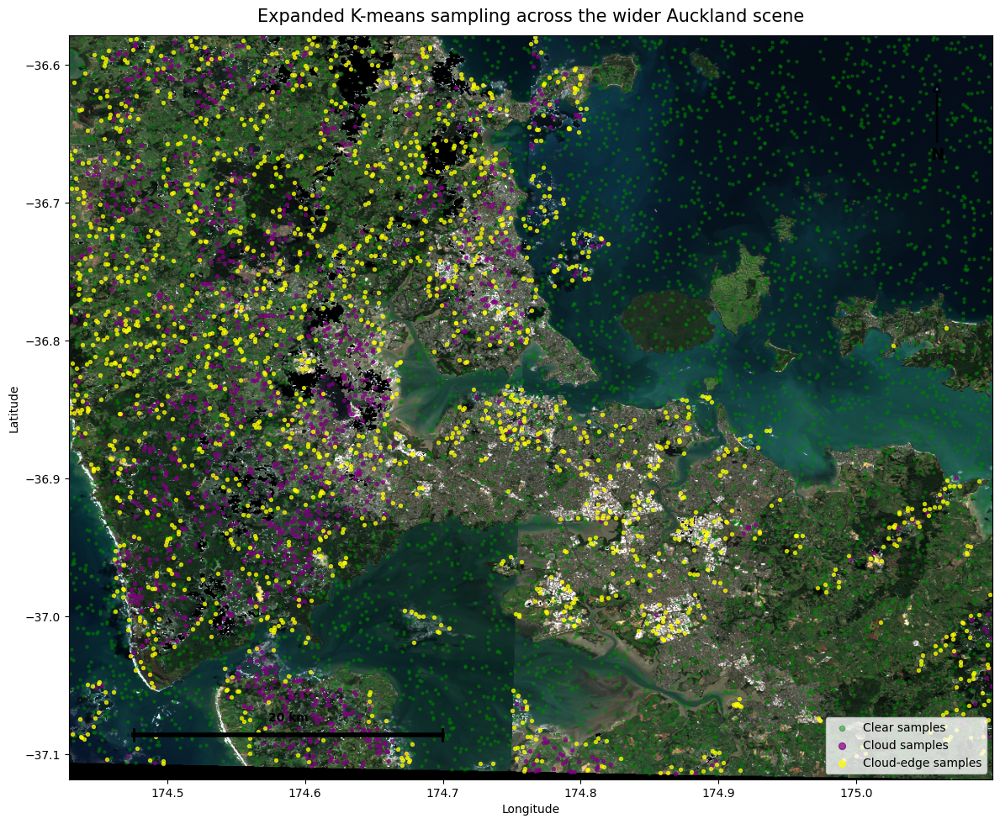

In [95]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

ax.imshow(
    sampling_rgb_array,
    extent=[xmin, xmax, ymin, ymax],
    origin='upper'
)

ax.scatter(
    clear_df_large['longitude'],
    clear_df_large['latitude'],
    s=5,
    c='green',
    alpha=0.45,
    label='Clear samples'
)

ax.scatter(
    cloud_df_large['longitude'],
    cloud_df_large['latitude'],
    s=8,
    c='purple',
    alpha=0.7,
    label='Cloud samples'
)

ax.scatter(
    edge_df_large['longitude'],
    edge_df_large['latitude'],
    s=8,
    c='yellow',
    alpha=0.7,
    label='Cloud-edge samples'
)

ax.set_title(
    'Expanded K-means sampling across the wider Auckland scene',
    fontsize=15,
    pad=12
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.legend(
    loc='lower right',
    frameon=True,
    fontsize=10,
    markerscale=2
)

ax.annotate(
    'N',
    xy=(0.94, 0.94),
    xytext=(0.94, 0.84),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=1.8
    )
)

mean_lat = (ymin + ymax) / 2

km_per_degree_lon = 111.32 * np.cos(np.radians(mean_lat))
scale_km = 20
scale_deg = scale_km / km_per_degree_lon

bar_x = xmin + (xmax - xmin) * 0.07
bar_y = ymin + (ymax - ymin) * 0.06

ax.plot(
    [bar_x, bar_x + scale_deg],
    [bar_y, bar_y],
    linewidth=4,
    c='black'
)

tick_height = (ymax - ymin) * 0.008

ax.plot(
    [bar_x, bar_x],
    [bar_y - tick_height, bar_y + tick_height],
    linewidth=2,
    c='black'
)

ax.plot(
    [bar_x + scale_deg, bar_x + scale_deg],
    [bar_y - tick_height, bar_y + tick_height],
    linewidth=2,
    c='black'
)

ax.text(
    bar_x + scale_deg / 2,
    bar_y + (ymax - ymin) * 0.015,
    '20 km',
    ha='center',
    va='bottom',
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'Q6_Figure1_expanded_sampling.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Figure:

In [81]:
# Comparing the original cloud mask with the whole-scene K-means refined mask.
# Both panels use the same extent so changes caused by the K-means edge
# classification can be compared directly.

rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 2500,
    'gamma': 1.1
}

rgb_img = s2_sr_mosaic.visualize(**rgb_vis)

original_mask_vis = cloudmask.selfMask().visualize(
    palette=['red']
)

refined_mask_vis = refined_mask.selfMask().visualize(
    palette=['yellow']
)

original_display = rgb_img.blend(original_mask_vis)
refined_display = rgb_img.blend(refined_mask_vis)

figure_region = large_region

In [83]:
original_array_q6 = geemap.ee_to_numpy(
    original_display,
    region=figure_region,
    scale=40
)

refined_array_q6 = geemap.ee_to_numpy(
    refined_display,
    region=figure_region,
    scale=40
)

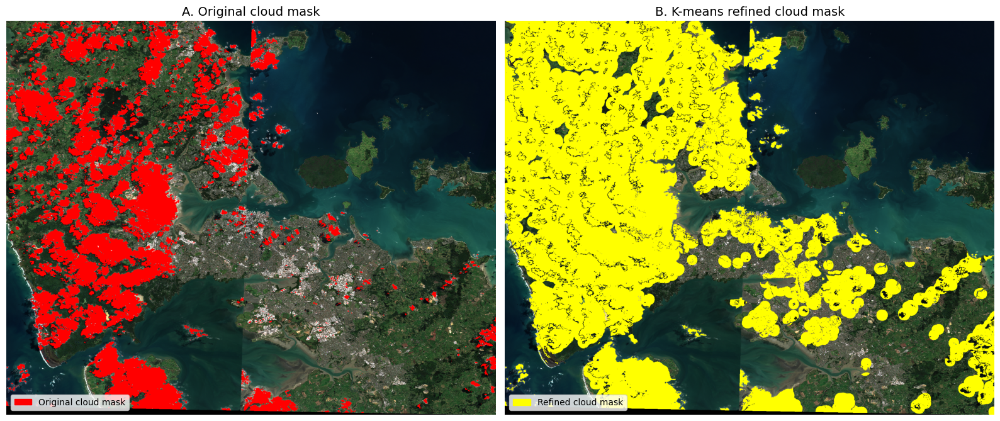

In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original
axes[0].imshow(original_array_q6)
axes[0].set_title('A. Original cloud mask', fontsize=14)
axes[0].axis('off')

# Refined
axes[1].imshow(refined_array_q6)
axes[1].set_title('B. K-means refined cloud mask', fontsize=14)
axes[1].axis('off')

# Legends
red_patch = mpatches.Patch(color='red', label='Original cloud mask')
yellow_patch = mpatches.Patch(color='yellow', label='Refined cloud mask')

axes[0].legend(handles=[red_patch], loc='lower left')
axes[1].legend(handles=[yellow_patch], loc='lower left')

plt.tight_layout()
plt.show()

# The whole-scene classification ran successfully, but the refined mask
# is much more aggressive than the original mask and includes many areas
# that appear to be clear land.

# This suggests that the current K-means clusters do not separate the Cloud and Clear classes well enough.